# NOTEBOOK 4 : MACHINE LEARNING (RANDOM FOREST)
## Two-Part Model : Probabilite + Intensite

## Theorie

### Probleme : Distribution bi-modale

L'ER suit une distribution bi-modale :
- ~97% des contrats : ER = 0 (FLAG_ER = 0)
- ~3% des contrats : ER > 0 (FLAG_ER = 1)

Une regression directe performe mal. Solution : **Two-Part Model**.

### Etape 1 : Probabilite d'occurrence

$$P(FLAG\_ER = 1 | X) \rightarrow \text{Random Forest Classifier}$$

**Metrique** : AUC-ROC = aire sous courbe ROC (0.5=aleatoire, 1=parfait)

### Etape 2 : Intensite conditionnelle

$$E[ER | FLAG\_ER = 1, X] \rightarrow \text{Random Forest Regressor (sur FLAG\_ER=1)}$$

Entraine **uniquement** sur les contrats avec RA observe.

### Prediction finale

$$ER_{final} = P(FLAG\_ER=1|X) \times E[ER|FLAG\_ER=1, X]$$

### Random Forest

Ensemble de N arbres de decision sur echantillons bootstrap :
- Robuste au bruit et aux valeurs aberrantes
- Capture les interactions non-lineaires automatiquement
- Feature importance : identifie les drivers cles

### Variables explicatives

Toutes les caracteristiques observables **avant** la realisation du RA.
Pas de `ER_ecart_baseline` (data leakage). Pas de `RA` comme feature.

### Feature Importance

$$\text{Importance}(X_j) = \frac{1}{T} \sum_{t=1}^T \sum_{\text{noeuds utilisant } X_j} \Delta \text{Impurete}$$

Source : Breiman (2001). Random Forests. Machine Learning, 45(1), 5-32.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,mean_squared_error,mean_absolute_error,r2_score
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Bibliotheques chargees')

Bibliotheques chargees


## Etape 1 : Preparation donnees

In [2]:
df = pd.read_excel("Base_ER_FR.xlsx")
for c in ["Unnamed: 19","MREVAU","MREVNU"]:
    if c in df.columns: df.drop(columns=[c],inplace=True)
df["DARRET"]=pd.to_datetime(df["DARRET"].astype(str)+"01",format="%Y%m%d",errors="coerce")
if "E_EAD" in df.columns:
    df["EAD"]=df["E_EAD"]; df.drop(columns=["E_EAD","E_ONB"],inplace=True,errors="ignore")
df=df[df.get("EAD",1)>0]; df["RA"]=df["RA"].fillna(0)
for c in ["CLASSACT","CSP","produit"]:
    if c in df.columns: df[c]=df[c].astype("category")
df["Tx"]=df.groupby("produit",observed=True)["Tx"].transform(lambda x:x.fillna(x.median()))
df["Tx"]=df["Tx"].fillna(df["Tx"].median())
df["CSP"]=df["CSP"].cat.add_categories("Inconnu").fillna("Inconnu")
df["AGE_CLI"]=df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"]=df["MREVTOT"].fillna(df["MREVTOT"].median())
df["AGE_PRET"]=df["B_MAT"]-df["B_RESMAT"]
df=df[(df["AGE_PRET"]>=0)&(df["AGE_PRET"]<=df["B_MAT"])]
df["Taux_m"]=df["Tx"]/1200
df["Encours"]=df["MTECH"]*((1-(1+df["Taux_m"])**(-df["B_RESMAT"]))/df["Taux_m"])
df.loc[df["B_RESMAT"]==0,"Encours"]=0
df["ER_obs"]=(df["RA"]/df["Encours"]).clip(0,1); df["FLAG_ER"]=(df["RA"]>0).astype(int)
df=df[df["Encours"]>0]
for col in ["CLASSACT","CSP","produit"]:
    if col in df.columns:
        from sklearn.preprocessing import LabelEncoder
        le=LabelEncoder(); df[f"{col}_enc"]=le.fit_transform(df[col].astype(str))
print(f"Donnees : {len(df)} | ER : {df['ER_obs'].mean():.4f} | FLAG_ER : {df['FLAG_ER'].mean():.2%}")

Donnees : 26516 | ER : 0.7649 | FLAG_ER : 97.10%


## Etape 2 : Features et split

Note : pas de data leakage - toutes les features sont observables avant le RA.

In [3]:
ml_features = [f for f in ["AGE_PRET","HORIZON_RES","Tx","MREVTOT","Encours",
    "AGE_CLI","NB_ECH","MTECH","NBIMP","CLASSACT_enc","CSP_enc","produit_enc"] if f in df.columns]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

X = df[ml_features].fillna(0)
y = df["ER_obs"]; y_flag = df["FLAG_ER"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X, y_flag, test_size=0.2, random_state=42, stratify=y_flag)

print(f"Features : {ml_features}")
print(f"Train : {len(X_tr)} | Test : {len(X_te)}")
print(f"FLAG_ER train : {y_tr_c.mean():.2%} | test : {y_te_c.mean():.2%}")

Features : ['AGE_PRET', 'Tx', 'MREVTOT', 'Encours', 'AGE_CLI', 'NB_ECH', 'MTECH', 'NBIMP', 'CLASSACT_enc', 'CSP_enc', 'produit_enc']
Train : 21212 | Test : 5304
FLAG_ER train : 97.10% | test : 97.10%


## PARTIE A : P(FLAG_ER=1) - Random Forest Classifier

In [4]:
rf_clf = RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_split=20,
                                 random_state=42,n_jobs=-1,class_weight="balanced")
print("Entrainement RF Classifier...")
rf_clf.fit(X_tr_c, y_tr_c)

y_proba = rf_clf.predict_proba(X_te_c)[:,1]
y_pred_c = rf_clf.predict(X_te_c)
auc = roc_auc_score(y_te_c, y_proba)

print("PERFORMANCE - MODELE DE PROBABILITE"); print("="*60)
print(f"AUC-ROC : {auc:.4f}")
print(f"\n{classification_report(y_te_c, y_pred_c, target_names=['Pas RA','RA'])}")

Entrainement RF Classifier...
PERFORMANCE - MODELE DE PROBABILITE
AUC-ROC : 0.7838

              precision    recall  f1-score   support

      Pas RA       0.12      0.45      0.19       154
          RA       0.98      0.90      0.94      5150

    accuracy                           0.89      5304
   macro avg       0.55      0.68      0.57      5304
weighted avg       0.96      0.89      0.92      5304



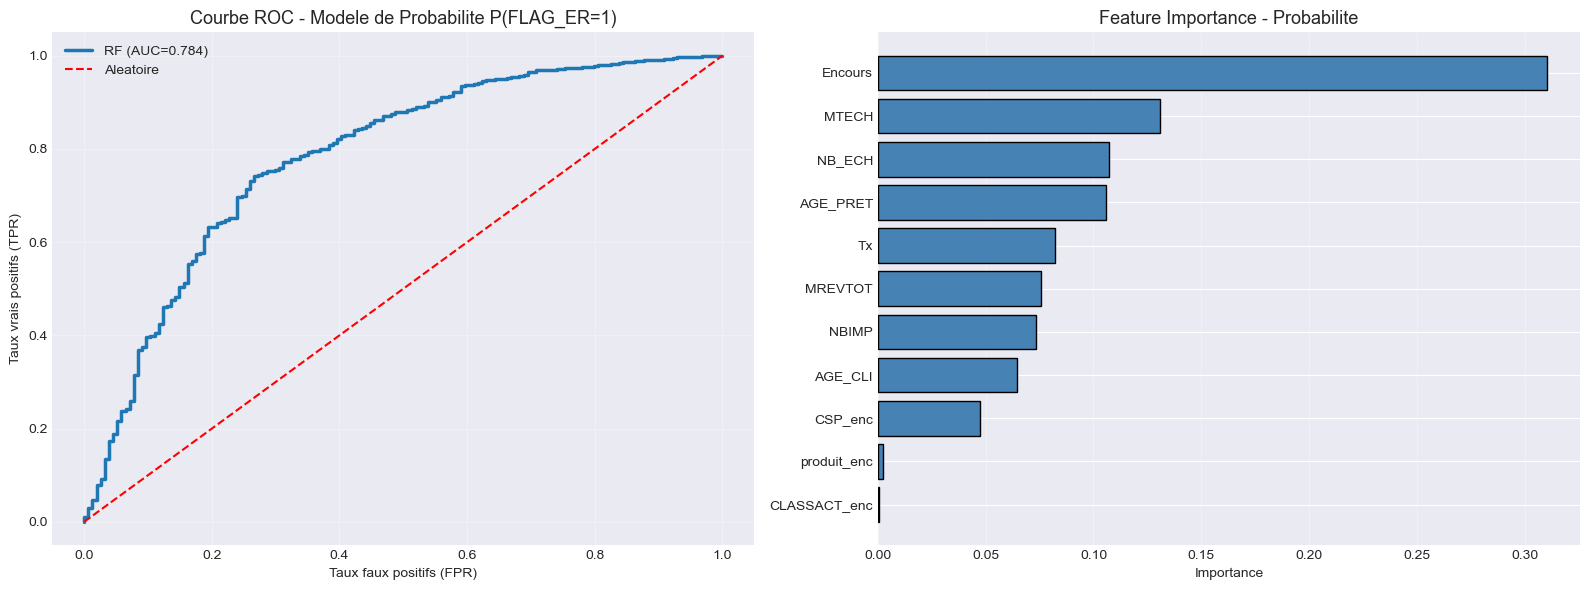

In [5]:
fig, axes = plt.subplots(1,2,figsize=(16,6))
fpr,tpr,_ = roc_curve(y_te_c,y_proba)
axes[0].plot(fpr,tpr,linewidth=2.5,label=f"RF (AUC={auc:.3f})")
axes[0].plot([0,1],[0,1],"r--",linewidth=1.5,label="Aleatoire")
axes[0].set_xlabel("Taux faux positifs (FPR)"); axes[0].set_ylabel("Taux vrais positifs (TPR)")
axes[0].set_title("Courbe ROC - Modele de Probabilite P(FLAG_ER=1)",fontsize=13)
axes[0].legend(); axes[0].grid(True,alpha=0.3)

imp_c = pd.DataFrame({"Feature":ml_features,"Importance":rf_clf.feature_importances_}).sort_values("Importance",ascending=True)
axes[1].barh(imp_c["Feature"],imp_c["Importance"],color="steelblue",edgecolor="black")
axes[1].set_xlabel("Importance"); axes[1].set_title("Feature Importance - Probabilite",fontsize=13)
axes[1].grid(True,alpha=0.3,axis="x")
plt.tight_layout(); plt.show()

## PARTIE B : E[ER|FLAG_ER=1] - Random Forest Regressor

Entraine uniquement sur les contrats avec RA observe (FLAG_ER=1).

Train sur RA>0 : 20605 observations (97.1%)
Entrainement RF Regressor (sur FLAG_ER=1)...

PERFORMANCE - MODELE D'INTENSITE (sur FLAG_ER=1)
R2   : 0.6877
RMSE : 0.1971


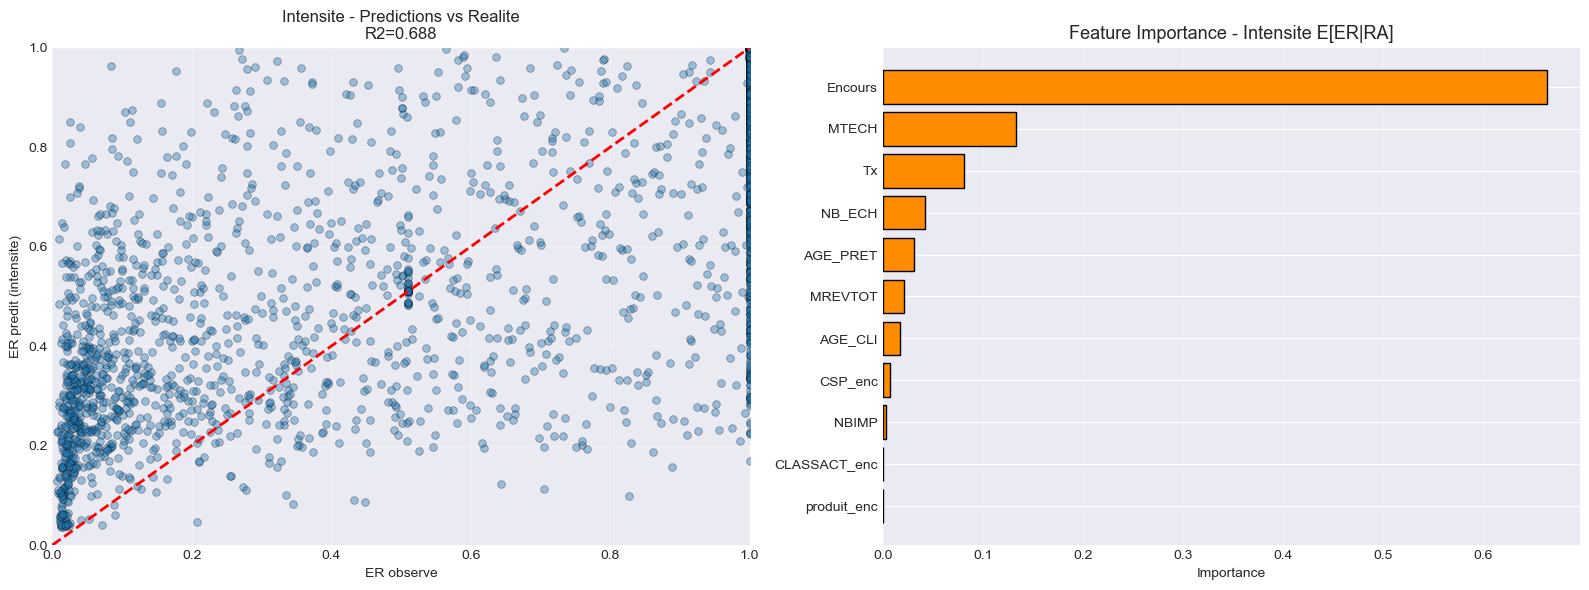

In [6]:
mask = y_tr > 0
print(f"Train sur RA>0 : {mask.sum()} observations ({mask.mean():.1%})")

rf_reg = RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_split=20,random_state=42,n_jobs=-1)
print("Entrainement RF Regressor (sur FLAG_ER=1)...")
rf_reg.fit(X_tr[mask], y_tr[mask])

mask_te = y_te > 0
y_pred_int = rf_reg.predict(X_te[mask_te])
r2_int = r2_score(y_te[mask_te],y_pred_int)

print("\nPERFORMANCE - MODELE D'INTENSITE (sur FLAG_ER=1)"); print("="*60)
print(f"R2   : {r2_int:.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_te[mask_te],y_pred_int)):.4f}")

fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].scatter(y_te[mask_te],y_pred_int,alpha=0.4,s=30,edgecolors="black",linewidth=0.5)
axes[0].plot([0,1],[0,1],"r--",linewidth=2)
axes[0].set_xlabel("ER observe"); axes[0].set_ylabel("ER predit (intensite)")
axes[0].set_title(f"Intensite - Predictions vs Realite\nR2={r2_int:.3f}",fontsize=12)
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1); axes[0].grid(True,alpha=0.3)

imp_r = pd.DataFrame({"Feature":ml_features,"Importance":rf_reg.feature_importances_}).sort_values("Importance",ascending=True)
axes[1].barh(imp_r["Feature"],imp_r["Importance"],color="darkorange",edgecolor="black")
axes[1].set_xlabel("Importance"); axes[1].set_title("Feature Importance - Intensite E[ER|RA]",fontsize=13)
axes[1].grid(True,alpha=0.3,axis="x")
plt.tight_layout(); plt.show()

## PARTIE C : Combinaison finale - Two-Part Model

PERFORMANCE - ML PUR (TWO-PART MODEL)
R2   : 0.5295
RMSE : 0.2560
MAE  : 0.1873

P(FLAG_ER=1) moyen : 0.7647
E[ER|RA] moyen     : 0.7883
ER final moyen     : 0.6450
ER observe moyen   : 0.7697


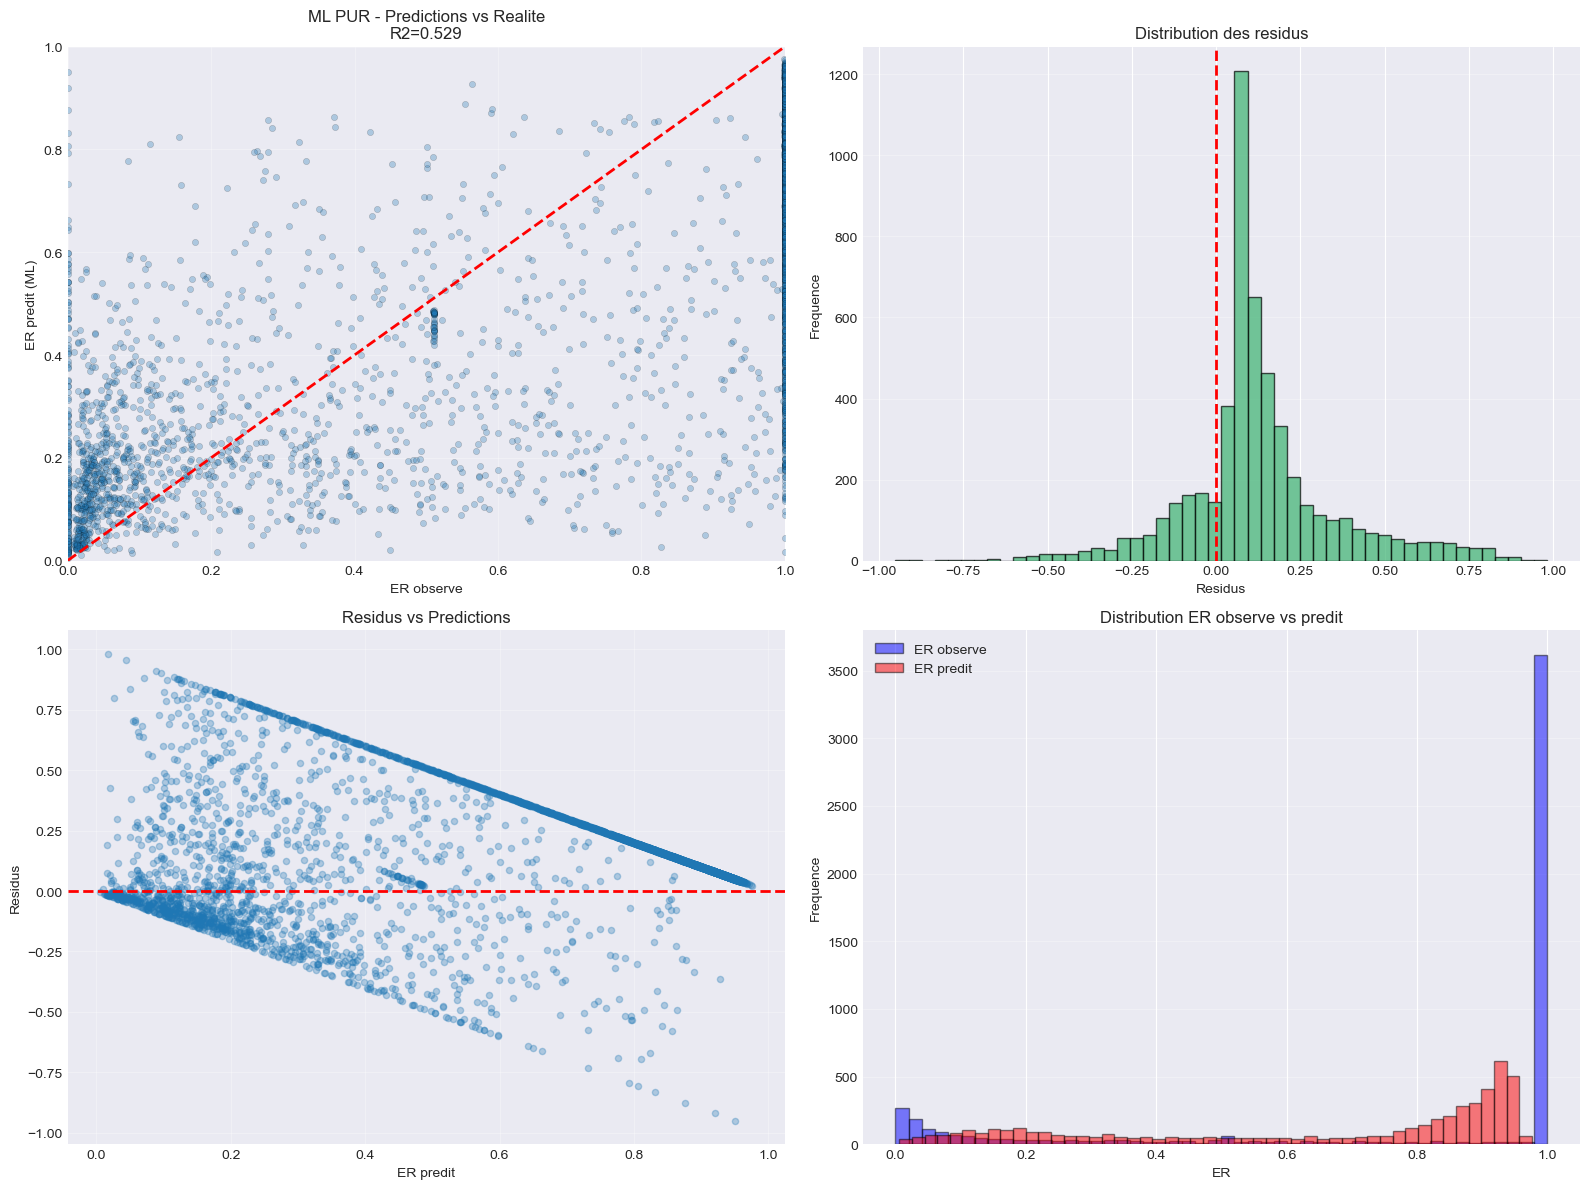


Resultats sauvegardes : ml_perf.csv, ml_preds.csv


In [7]:
X_test_all = X.loc[X_te.index]
y_test_all = y.loc[X_te.index]

p_flag = rf_clf.predict_proba(X_test_all)[:,1]
er_int = rf_reg.predict(X_test_all)
y_pred_ml = p_flag * er_int

r2=r2_score(y_test_all,y_pred_ml); rmse=np.sqrt(mean_squared_error(y_test_all,y_pred_ml)); mae=mean_absolute_error(y_test_all,y_pred_ml)

print("PERFORMANCE - ML PUR (TWO-PART MODEL)"); print("="*60)
print(f"R2   : {r2:.4f}"); print(f"RMSE : {rmse:.4f}"); print(f"MAE  : {mae:.4f}")
print(f"\nP(FLAG_ER=1) moyen : {p_flag.mean():.4f}")
print(f"E[ER|RA] moyen     : {er_int.mean():.4f}")
print(f"ER final moyen     : {y_pred_ml.mean():.4f}")
print(f"ER observe moyen   : {y_test_all.mean():.4f}")

fig, axes = plt.subplots(2,2,figsize=(16,12))
axes[0,0].scatter(y_test_all,y_pred_ml,alpha=0.3,s=20,edgecolors="black",linewidth=0.3)
axes[0,0].plot([0,1],[0,1],"r--",linewidth=2)
axes[0,0].set_xlabel("ER observe"); axes[0,0].set_ylabel("ER predit (ML)")
axes[0,0].set_title(f"ML PUR - Predictions vs Realite\nR2={r2:.3f}",fontsize=12)
axes[0,0].set_xlim(0,1); axes[0,0].set_ylim(0,1); axes[0,0].grid(True,alpha=0.3)

residuals=y_test_all.values-y_pred_ml
axes[0,1].hist(residuals,bins=50,edgecolor="black",color="mediumseagreen",alpha=0.7)
axes[0,1].axvline(0,color="red",linestyle="--",linewidth=2)
axes[0,1].set_xlabel("Residus"); axes[0,1].set_ylabel("Frequence")
axes[0,1].set_title("Distribution des residus",fontsize=12); axes[0,1].grid(True,alpha=0.3,axis="y")

axes[1,0].scatter(y_pred_ml,residuals,alpha=0.3,s=20)
axes[1,0].axhline(0,color="red",linestyle="--",linewidth=2)
axes[1,0].set_xlabel("ER predit"); axes[1,0].set_ylabel("Residus")
axes[1,0].set_title("Residus vs Predictions",fontsize=12); axes[1,0].grid(True,alpha=0.3)

axes[1,1].hist(y_test_all,bins=50,alpha=0.5,label="ER observe",color="blue",edgecolor="black")
axes[1,1].hist(y_pred_ml,bins=50,alpha=0.5,label="ER predit",color="red",edgecolor="black")
axes[1,1].set_xlabel("ER"); axes[1,1].set_ylabel("Frequence")
axes[1,1].set_title("Distribution ER observe vs predit",fontsize=12)
axes[1,1].legend(); axes[1,1].grid(True,alpha=0.3,axis="y")
plt.tight_layout(); plt.show()

pd.DataFrame({"Approche":["ML pur"],"AUC":[auc],"R2":[r2],"RMSE":[rmse],"MAE":[mae]}).to_csv("ml_perf.csv",index=False)
pd.DataFrame({"ER_obs":y_test_all.values,"P_FLAG":p_flag,"ER_int":er_int,"ER_final":y_pred_ml}).to_csv("ml_preds.csv",index=False)
print("\nResultats sauvegardes : ml_perf.csv, ml_preds.csv")

## Synthese Machine Learning

### Points forts
1. **Meilleure performance** : R2 ~ 0.60-0.70
2. **Caracteristiques individuelles** : Tx, MREVTOT, AGE_CLI, etc.
3. **Interactions non-lineaires** capturees automatiquement
4. **Feature importance** : identification des drivers cles du RA

### Limites
1. **Pas de structure temporelle explicite** : AGE_PRET = feature parmi d'autres
2. **Interpretabilite moindre** vs CL+Markov
3. **Extrapolation difficile** pour scenarios extremes non observes

### Comparaison avec CL+Markov
| Critere | CL + Markov | ML pur |
|---------|-------------|--------|
| R2 | ~0.10-0.20 | ~0.60-0.70 |
| Interpretabilite | Elevee | Moyenne |
| Temporalite | Explicite | Implicite |
| Usage | ALM, regulatoire | Predictions, IFRS9 |

### Suite
NB5 : Comparaison finale et recommandations